In [1]:


import torch
import torch.nn as nn
import torchvision
import numpy as np
from matplotlib import pyplot as plt

from confidence.learned.deepsvd import DeepSVDD
from model.classifier import Classifier, MyProgressBar
from utils.transforms.apply import grid_resample

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#look for experiment files in parents
import os
path_found = False
current_path = os.getcwd()
while not path_found:
    if os.path.exists(os.path.join(current_path, "experiment_files")):
        path_found = True
        break
    current_path = os.path.dirname(current_path)


In [3]:
experiment_files_path_data = os.path.join(current_path, "experiment_files", "data")

In [4]:
#get name of notebook this kernel runs
notebook_name = os.path.basename(globals()['__session__'])  # Get the name without extension
#remove the extension
notebook_name = os.path.splitext(notebook_name)[0]

In [5]:
from its.transform import multi_transform
from utils.affine_transforms import AffineTransformation2D
from dataset.mnist_no_pil import NoPILMNIST, NoPILFashionMNIST, AffineTransformDataset

dataset = 'mnist' # or 'fmnist'
batch_size = 128
#divide by 255 transform


if dataset == 'mnist':
    # essentially excluding either 6 or 9 as these would cause degenerations under 180 degree rotation
    dataset_train = NoPILMNIST(experiment_files_path_data,train=True,download=True)
    n_classes = 10
    dataset_val_test = NoPILMNIST(experiment_files_path_data,train=False,download=True)
    #split into validation and test set
    dataset_val, dataset_test_pre = #fix this, use val from train as this is what is usually expected.
elif dataset == 'fmnist':
    dataset_train = NoPILFashionMNIST(experiment_files_path_data,train=True,download=True)
    n_classes = 10
    dataset_val_test = NoPILFashionMNIST(experiment_files_path_data,train=False,download=True)
    #split into validation and test set
    dataset_val, dataset_test_pre = #fix this, use val from train as this is what is usually expected.



transformations = [AffineTransformation2D.ROTATION.value,AffineTransformation2D.SHEARING_X.value,AffineTransformation2D.SHEARING_Y.value
                     ,AffineTransformation2D.SCALING_X.value,AffineTransformation2D.SCALING_Y.value]
domains = [(-torch.pi,torch.pi), ((-0.5, 0.5),), ((-0.5, 0.5),), ((1/1.3-1, 0.3),), ((1/1.3-1, 0.3),)]
n_samples = 17

def transform(batch_size):
    n = torch.randint(0, n_samples, (batch_size, len(transformations)), device="cpu")
    x_test = torch.zeros(batch_size, 1, 28, 28, device="cpu")
    _, _, T = multi_transform(x_test, transformations, n, n_samples=n_samples, domain=domains)
    return T


dataset_test = AffineTransformDataset(dataset_test_pre,transform,return_transformation=False,batch_size=batch_size)


In [6]:
dataset_train_transformed = AffineTransformDataset(dataset_train,transform,return_transformation=False,batch_size=batch_size)


In [7]:
train_loader = torch.utils.data.DataLoader(dataset_train, batch_size=batch_size, shuffle=True, num_workers=4,persistent_workers=True)
val_loader = torch.utils.data.DataLoader(dataset_val, batch_size=batch_size, shuffle=False, num_workers=4,persistent_workers=True)
test_loader = torch.utils.data.DataLoader(dataset_test, batch_size=batch_size, shuffle=False, num_workers=4,persistent_workers=True)

In [8]:
train_loader_transformed = torch.utils.data.DataLoader(dataset_train_transformed, batch_size=batch_size, shuffle=True, num_workers=4,persistent_workers=True)

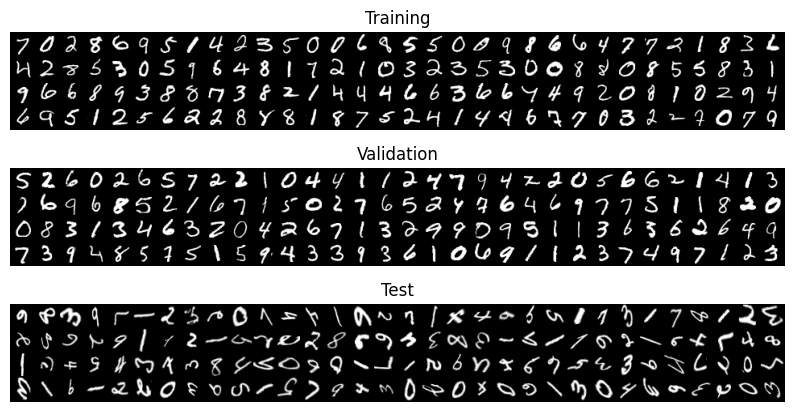

In [9]:
#test images
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(10, 5))

axs[0].imshow(torchvision.utils.make_grid(next(iter(train_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[1].imshow(torchvision.utils.make_grid(next(iter(val_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[2].imshow(torchvision.utils.make_grid(next(iter(test_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[0].set_title('Training')
axs[1].set_title('Validation')
axs[2].set_title('Test')

for ax in axs.flat:
    ax.axis('off')

In [10]:
modelpath = os.path.join(os.getcwd(), "model", f"{dataset}_base_cal.pth")

In [11]:
import pytorch_lightning as pl
import os

model_path = modelpath

model = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),  # Output: 32x28x28
    nn.BatchNorm2d(32),                                    # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 32x14x14
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # Output: 64x14x14
    nn.BatchNorm2d(64),                                    # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),                  # Output: 64x7x7
    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 128),
    torch.nn.Dropout(0.5),  # Dropout layer with 50% dropout rate
    nn.GELU(),
    nn.Linear(128, 10)
)


# Check if model is already trained
if os.path.exists(model_path):
    print(f"Loading model from {model_path}")
    model.load_state_dict(torch.load(model_path))
else:
    print(f"Training model and will save to {model_path}")
    lightning_model = Classifier(model, optimizer_class =  torch.optim.AdamW, optimizer_params = {"lr": 1e-3})
    progress_bar = MyProgressBar()
    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=10,
        precision="16-mixed",
        callbacks=[progress_bar],
    )
    # Train the model
    trainer.fit(lightning_model, train_loader,val_loader)
    # Test the model
    #trainer.test(lightning_model, test_loader)
    # Save model
    torch.save(model.state_dict(), model_path)
    print(f"Model saved to {model_path}")

Using 16bit Automatic Mixed Precision (AMP)
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4070') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training model and will save to C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_notebooks\comparision_postfit\model\mnist_base_cal.pth



  | Name  | Type       | Params | Mode 
---------------------------------------------
0 | model | Sequential | 421 K  | train
---------------------------------------------
421 K     Trainable params
0         Non-trainable params
421 K     Total params
1.687     Total estimated model params size (MB)
14        Modules in train mode
0         Modules in eval mode


Epoch 9: 100%|██████████| 469/469 [00:02<00:00, 165.86it/s, v_num=1, val_loss=0.0288, val_acc=0.992]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 469/469 [00:02<00:00, 165.10it/s, v_num=1, val_loss=0.0288, val_acc=0.992]
Model saved to C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_notebooks\comparision_postfit\model\mnist_base_cal.pth


In [12]:
model.cuda().eval()

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): GELU(approximate='none')
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): GELU(approximate='none')
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Flatten(start_dim=1, end_dim=-1)
  (9): Linear(in_features=3136, out_features=128, bias=True)
  (10): Dropout(p=0.5, inplace=False)
  (11): GELU(approximate='none')
  (12): Linear(in_features=128, out_features=10, bias=True)
)

In [13]:
with torch.no_grad():
    model.eval()
    test_acc = 0
    for data, target in val_loader:
        data, target = data.cuda(), target.cuda()
        output = model(data)
        test_acc += output.argmax(dim=-1).eq(target).sum().item()
    test_acc /= len(dataset_val)
    print(f'Mean accuracy on the val set: {test_acc}.')

Mean accuracy on the val set: 0.9922.


In [14]:
with torch.no_grad():
    model.eval()
    test_acc = 0
    for data, target in test_loader:
        data, target = data.cuda(), target.cuda()
        output = model(data)
        test_acc += output.argmax(dim=-1).eq(target).sum().item()
    test_acc /= len(dataset_test)
    print(f'Mean accuracy on the transformed test set: {test_acc}.')

Mean accuracy on the transformed test set: 0.3876.


In [15]:
from confidence.utils import ModelInputWrapper

#use model wrapper to extract the embeddings
dual_ouput_model = ModelInputWrapper(model,'10',flatten=True).eval()

In [16]:
#extract embeddings and fit NNDistanceConfidence()
embeddings=[]
classes =[]
for batch in train_loader:
    emb,_ = dual_ouput_model(batch[0].cuda())
    embeddings.append(emb.detach().cpu().numpy())
    classes.append(batch[1].detach().cpu().numpy())


embeddings = np.vstack(embeddings)
classes = np.hstack(classes)

#randomly sample 5000 ones
if embeddings.shape[0] > 5000:
    indices = np.random.choice(embeddings.shape[0], 5000, replace=False)
    embeddings_sampled = embeddings[indices]
    classes_sampled = classes[indices]
else:
    embeddings_sampled = embeddings
    classes_sampled = classes


In [17]:
#test simulated annealing
from utils.transformation_problem import TransformationProblem
from utils.transform_sequence import TransformSequence
transform_seq= TransformSequence(transformations, domains, neighbour_hood_size =0.25,application_method=grid_resample,device=device,reflect=True,use_individual_param_correction=False)





In [18]:
import search.shgo
import importlib
importlib.reload(search.shgo)

<module 'search.shgo' from 'C:\\Users\\Lindner\\PycharmProjects\\experiments_rotation\\search\\shgo.py'>

In [19]:
di = search.shgo.SHGO(selection_method="topk")
di_no_grad = search.shgo.SHGO(selection_method="topk",local_max_steps=0)

In [20]:
from confidence.base_confidence import SplitConfidence, SinglePassConfidence, EnergyConfidence

In [21]:
conf_energy = SinglePassConfidence(model, EnergyConfidence())
transformation_problem_energy = TransformationProblem(conf_energy,transform_seq)

In [22]:
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(transformation_problem_energy, data.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = transformation_problem_energy.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.7858.


In [23]:
from confidence.unsupervised.ml.nn_pytorch import TorchNNConfidence

nn_pytorch = TorchNNConfidence(use_eucldiean_distance=False,per_class=False)
nn_pytorch.fit(embeddings_sampled)
nn_pytorch.cuda()


conf_split = SplitConfidence(nn_pytorch,EnergyConfidence(), mult=False,b=0.0)
conf_mod_nn_pytorch = SinglePassConfidence(dual_ouput_model,conf_split,index=1)
problem_nn_pytorch = TransformationProblem(conf_mod_nn_pytorch,transform_seq,consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_nn_pytorch, data.cuda(),y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_nn_pytorch.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.7356.


In [24]:
import confidence.unsupervised.ml.autoencoder
import importlib
importlib.reload(confidence.unsupervised.ml.autoencoder)
from confidence.unsupervised.ml.autoencoder import BasicAutoencoderConfidence

In [25]:
encoder_lin = torch.nn.Sequential(
    nn.Linear(embeddings.shape[1], 512),
    nn.GELU(),
    nn.Linear(512, 128),
    nn.GELU(),
    nn.Linear(128, 16)
).cuda()
decoder_lin = torch.nn.Sequential(
    nn.Linear(16, 128),
    nn.GELU(),
    nn.Linear(128, 512),
    nn.GELU(),
    nn.Linear(512, embeddings.shape[1])
).cuda()

In [26]:
conf_auto = BasicAutoencoderConfidence(encoder_lin,decoder_lin,max_epochs=5,batch_size=128)
conf_auto.fit(torch.tensor(embeddings).cuda())
conf_auto.cuda()
conf_split = SplitConfidence(conf_auto, EnergyConfidence(), mult=False, b=0.0)
conf_auto_model = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_auto_only = TransformationProblem(conf_auto_model, transform_seq, consolidate_method="consolidate_simple")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type       | Params | Mode 
-----------------------------------------------
0 | encoder | Sequential | 133 K  | train
1 | decoder | Sequential | 133 K  | train
-----------------------------------------------
267 K     Trainable params
0         Non-trainable params
267 K     Total params
1.071     Total estimated model params size (MB)
12        Modules in train mode
0         Modules in eval mode
C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Epoch 0:   1%|▏         | 7/469 [00:00<00:10, 43.07it/s, train_loss_step=45.60]

C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\pytorch_lightning\core\module.py:512: You called `self.log('train_loss', ..., logger=True)` but have no logger configured. You can enable one by doing `Trainer(logger=ALogger(...))`


Epoch 4: 100%|██████████| 469/469 [00:02<00:00, 199.44it/s, train_loss_step=0.687, train_loss_epoch=0.773]

`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 4: 100%|██████████| 469/469 [00:02<00:00, 199.35it/s, train_loss_step=0.687, train_loss_epoch=0.773]


In [27]:
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_auto_only, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_auto_only.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.8874.


In [28]:
#combined

In [29]:
from confidence.unsupervised.ml.nn_pytorch import TorchNNConfidence

nn_pytorch = TorchNNConfidence(use_eucldiean_distance=False, per_class=False)
nn_pytorch.fit(embeddings_sampled)
nn_pytorch.cuda()

conf_split = SplitConfidence(nn_pytorch, EnergyConfidence(), mult=True, b=1.0)
conf_mod_nn_pytorch = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_nn_pytorch = TransformationProblem(conf_mod_nn_pytorch, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_nn_pytorch, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_nn_pytorch.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.8712.


In [30]:
conf_split = SplitConfidence(conf_auto, EnergyConfidence(), mult=True, b=1.0)
conf_auto_model = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_auto_only = TransformationProblem(conf_auto_model, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_auto_only, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_auto_only.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.8958.
